## Dataset Collection & Annotation

---


## Dataset Sources

Datasets for object detection can come from:
- **Roboflow**: Pre-annotated datasets ready for YOLO.
- **Kaggle**: Open-source datasets.
- **Custom CCTV footage** or **web scraping**.

For this project, we use a **Roboflow dataset** that already has bounding box annotations.

## Annotation Tools

If annotating manually, common tools are:
- **LabelImg**: GUI-based labeling for YOLO.
- **Roboflow Online Annotation**: Annotate online and export in YOLO format.

Since our dataset is pre-annotated, we skip manual labeling.  



## YOLO Data Format

YOLO works better with a **flat folder structure**:


- `images/` contains image files (.jpg/.png).  
- `labels/` contains YOLO label files (.txt) with bounding boxes.  

**Train / Val / Test Splits:**
- **Train**: Model updates weights.  
- **Validation**: Checks performance during training.  
- **Test**: Evaluates final model performance.

**data.yaml** contains:
- Number of classes (`nc`)  
- Class names (`names`)  
- Paths to train, val, test images


# Step 1:  Accessing Roboflow Helmet Dataset


Even though we **already have the dataset in Drive**, it's important to know **how to download datasets from Roboflow**.  

### Steps to get the dataset:

1. Go to [Roboflow helmet detection website](https://universe.roboflow.com/construction-helmet/construction-helmet-detection/dataset/2).  
2. Create an account / login.  
3. Search for **"Bike Helmet Detection"** dataset.  
4. Click on **Download** → select **YOLOv8 format**.  
5. Roboflow will give you an **API key** and a few lines of code to download the dataset in Python, like this:

### Important Considerations

1. api_key is personal and never share it publicly.

2. The dataset.download("yolov8") command downloads images and annotations in Roboflow default folder structure.

3. Normally, you would run this to get the dataset. For our lecture, we will skip this step and use the already restructured dataset in Drive.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="zU1jxv7QZaxtalVrglkc")
project = rf.workspace("bike-helmets").project("bike-helmet-detection-2vdjo")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 107.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Bike-Helmet-Detection-2 in yolov8:: 100%|██████████| 7482/7482 [00:00<00:00, 8726.74it/s] 



---

#Step 2: Conceptual Restructuring of Dataset

```markdown
## Original Roboflow Structure

When downloaded from Roboflow, the dataset looks like this:
'''
construction-helmet-detection-2/
├─ train/
│ ├─ images/
│ └─ labels/
├─ valid/
│ ├─ images/
│ └─ labels/
└─ test/
├─ images/
└─ labels/




## Desired YOLO Flat Structure

We want this structure for YOLOv8:



```
```dataset/
├─ images/
│ ├─ train/
│ ├─ val/
│ └─ test/
├─ labels/
│ ├─ train/
│ ├─ val/
│ └─ test/
└─ data.yaml



### Explanation:

- We separate top-level `images/` and `labels/` folders, each containing train/val/test subfolders.  
- This structure is cleaner and easier to reference in `data.yaml`.


In [ ]:
# Simulate restructuring for demonstration (no actual files are moved)
original_structure = ["train/images/img1.jpg", "train/labels/img1.txt",
                      "valid/images/img2.jpg", "valid/labels/img2.txt",
                      "test/images/img3.jpg", "test/labels/img3.txt"]

print("Original Roboflow structure:")
for f in original_structure:
    print(f" - {f}")

print("\nRestructured YOLO flat structure (conceptual):")
restructured_structure = ["images/train/img1.jpg", "labels/train/img1.txt",
                          "images/val/img2.jpg", "labels/val/img2.txt",
                          "images/test/img3.jpg", "labels/test/img3.txt"]

for f in restructured_structure:
    print(f" - {f}")


Original Roboflow structure:
 - train/images/img1.jpg
 - train/labels/img1.txt
 - valid/images/img2.jpg
 - valid/labels/img2.txt
 - test/images/img3.jpg
 - test/labels/img3.txt

Restructured YOLO flat structure (conceptual):
 - images/train/img1.jpg
 - labels/train/img1.txt
 - images/val/img2.jpg
 - labels/val/img2.txt
 - images/test/img3.jpg
 - labels/test/img3.txt


# Step 3: Check the number of images within the dataset

In [ ]:
# Count images per split
import os

DATASET_ROOT = "/content/Bike-Helmet-Detection-2"

for split in ["train", "valid", "test"]:
    split_path = os.path.join(DATASET_ROOT, split, "images")  # actual path
    if os.path.exists(split_path):
        n = len(os.listdir(split_path))
        print(f"{split}: {n} images")
    else:
        print(f"{split}: folder not found")



train: 3546 images
valid: 126 images
test: 63 images


# Step 4: Simple visualization of training data and its labels

Corresponding YOLO label file: BikesHelmets449_png_jpg.rf.5055a15e47c0ce00e9e1f730efdab59a.txt
1 0.41586538461538464 0.03245192307692308 0.04326923076923077 0.06490384615384616
0 0.234375 0.19951923076923078 0.08413461538461539 0.03365384615384615
0 0.11298076923076923 0.19471153846153846 0.04326923076923077 0.04326923076923077
0 0.8990384615384616 0.027644230769230768 0.1971153846153846 0.055288461538461536
0 0.9230769230769231 0.2644230769230769 0.14903846153846154 0.09134615384615384
0 0.7067307692307693 0.31850961538461536 0.14903846153846154 0.19951923076923078


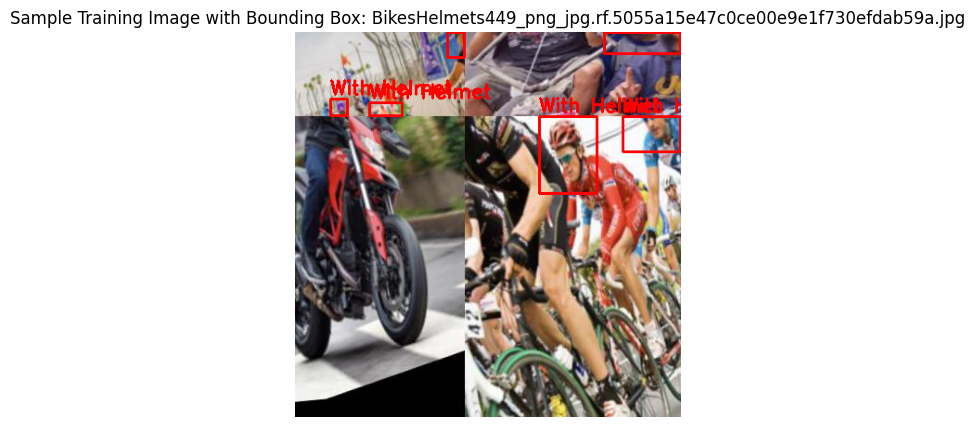

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Pick a sample image and its label
img_dir = os.path.join(DATASET_ROOT, "train/images")
lbl_dir = os.path.join(DATASET_ROOT, "train/labels")

sample_img = os.listdir(img_dir)[0]
sample_lbl = os.path.splitext(sample_img)[0] + ".txt"   # match image -> label file

# Read image
img = cv2.imread(os.path.join(img_dir, sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Read label file
with open(os.path.join(lbl_dir, sample_lbl)) as f:
    lines = f.readlines()
    print(f"Corresponding YOLO label file: {sample_lbl}")
for line in lines:
    print(line.strip())

# Define class names (edit as per your dataset)
class_names = ["With Helmet", "Without Helmet"]

# Draw bounding boxes
for line in lines:
    cls, x_c, y_c, bw, bh = map(float, line.strip().split())
    cls = int(cls)

    # Convert YOLO normalized coords → pixel coords
    x_c, y_c, bw, bh = x_c * w, y_c * h, bw * w, bh * h
    x1, y1 = int(x_c - bw/2), int(y_c - bh/2)
    x2, y2 = int(x_c + bw/2), int(y_c + bh/2)

    # Draw rectangle
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img, class_names[cls], (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

# Show result
plt.figure(figsize=(7, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Sample Training Image with Bounding Box: {sample_img}")
plt.show()


# Understanding YOLO Label Files

Each YOLO label file corresponds to **one image** and contains **one line per object**.  

The format of each line is:

`<class_id> <x_center> <y_center> <width> <height>`

### Fields:

- **class_id**: Integer representing the object class.  
  - `0` = with helmet  
  - `1` = without helmet  

- **x_center, y_center**: Center of the bounding box, **normalized** relative to image width and height (0 to 1).  
  - Example: `0.5` → middle of the image along that axis.  

- **width, height**: Size of the bounding box, also **normalized** (0 to 1) relative to image width and height.  

---

### Example:

Line from above output file:  `0 0.2765625 0.67578125 0.0734375 0.0578125`

Interpretation:

- `0` → class “with_helmet”  
- `x_center = 0.25625` → ~25.6% from left of the image  
- `y_center = 0.6234375` → ~62.3% from top of the image  
- `width = 0.071875` → box width = 7.2% of image width  
- `height = 0.08671875` → box height = 8.7% of image height  

This defines a rectangle around a helmet in the image. Each subsequent line represents **another helmet** in the same image.

---

**Key Points:**

- YOLO uses **normalized coordinates** so it works regardless of image resolution.  
- During training, these labels guide the model to predict **bounding boxes** and **class probabilities**.




## Model Training with YOLOv8

In [ ]:
!apt-get install tree -qq

Selecting previously unselected package tree.
(Reading database ... 126441 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!pip install ultralytics --quiet

import os, yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Verify dataset structure
!tree /content/Bike-Helmet-Detection-2 -L 2

# Load data.yaml from Colab dataset
DATA_YAML_PATH = "/content/Bike-Helmet-Detection-2/data.yaml"
with open(DATA_YAML_PATH) as f:
    data_yaml = yaml.safe_load(f)

print("✅ Classes:", data_yaml["names"])



/content/Bike-Helmet-Detection-2
├── data.yaml
├── README.dataset.txt
├── README.roboflow.txt
├── test
│   ├── images
│   └── labels
├── train
│   ├── images
│   └── labels
└── valid
    ├── images
    └── labels

9 directories, 3 files
✅ Classes: ['With Helmet', 'Without Helmet']


## Train the YOLOv8 Model

We now train YOLOv8 using our dataset.

Key parameters:
- **epochs (50)** → number of passes over the dataset.
- **imgsz (640)** → input image resolution.
- **batch (16)** → images processed in each step.
- **optimizer (AdamW)** → optimizer for learning.
- **lr0 (1e-3)** → initial learning rate.
- **patience (15)** → early stopping if no improvement.
- **amp (True)** → automatic mixed precision (faster on GPU).
- **project/name** → folder where outputs are saved.
- **save_period (5)** → save weights every 5 epochs.

Training outputs:
- `last.pt` → final weights.
- `best.pt` → best performing weights on validation set.
- `results.csv` → metrics and loss logs.


In [ ]:
# Load YOLOv8 small model
model = YOLO("yolov8s.pt")

# Train the model
results = model.train(
    data=DATA_YAML_PATH,
    epochs=30,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=1e-3,
    patience=15,
    amp=True,
    project="/content/helmet_yolov8_runs",
    name="exp",
    exist_ok=True,
    save_period=5
)

print("✅ Training finished")


Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bike-Helmet-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, perspective=0.0, plots=

## Training Configuration

- **Epochs:** 30  
- **Batch size:** 16  
- **Optimizer:** AdamW  
- **Initial learning rate:** 0.001, decayed with `lrf=0.01`  

**Losses monitored:**  
- `box_loss` – localization error  
- `cls_loss` – classification error  
- `dfl_loss` – bounding box distribution loss  

**Other settings:**  
- Freeze applied to some layers for fine-tuning  
- `patience=15` → early stopping patience  
- Mixed precision (`amp=True`)  
- Logging enabled (`plots=True`)  

---

## Training Progress

**Loss trends:**  
- Initial `box_loss` ~1.83 → final ~1.12  
- Initial `cls_loss` ~1.92 → final ~0.61  
- Initial `dfl_loss` ~1.60 → final ~1.15  
- Loss consistently decreasing → stable learning  

**mAP50 performance on validation set:**  
- Early epochs: ~0.48  
- Mid training (epoch 15–20): 0.78  
- End (epoch 30): 0.831  
- Very solid for only 30 epochs on a relatively small dataset  

**Class-wise performance:**  
- **With Helmet:** Precision ~0.81, Recall ~0.89, mAP50 ~0.905 ✅  
- **Without Helmet:** Precision ~0.77, Recall ~0.65, mAP50 ~0.737  

> Model detects “with helmet” more reliably, possibly due to more balanced or clearer samples  

---

## Inference & Speed

**Speed per image:**  
- Preprocess: 0.2 ms  
- Inference: 5 ms  
- Postprocess: 7.3 ms  

> Lightweight and suitable for real-time applications (like CCTV helmet monitoring)  

---

## Key Takeaways

- The model trained efficiently with good precision and recall, especially for the "with helmet" class  
- Minor imbalance for “without helmet” detection could be improved with more data or targeted augmentation  
- Using YOLOv8 small keeps inference fast, ideal for edge devices  
- Training looks stable: loss decreasing and mAP steadily improving


Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


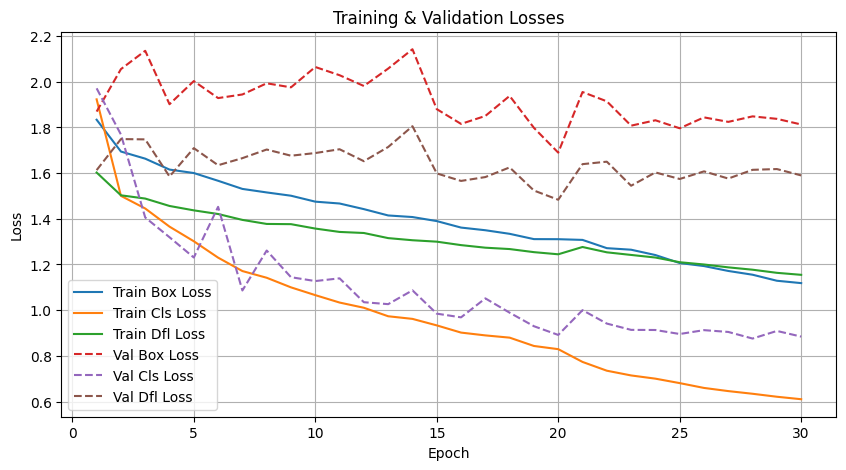

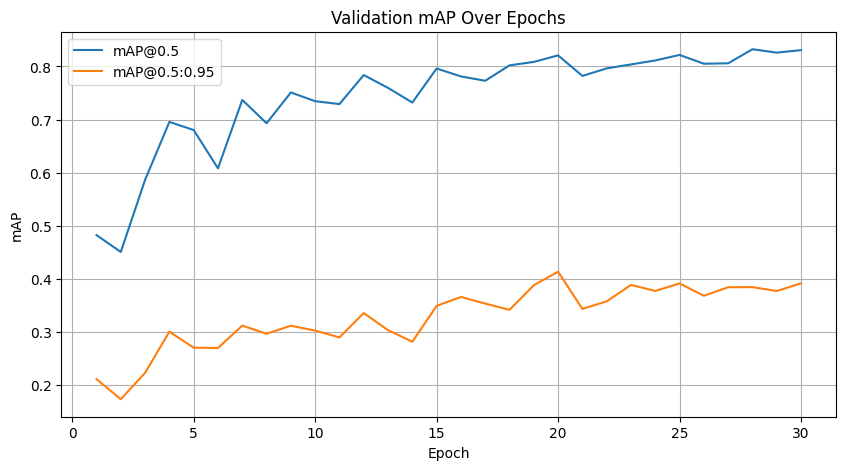

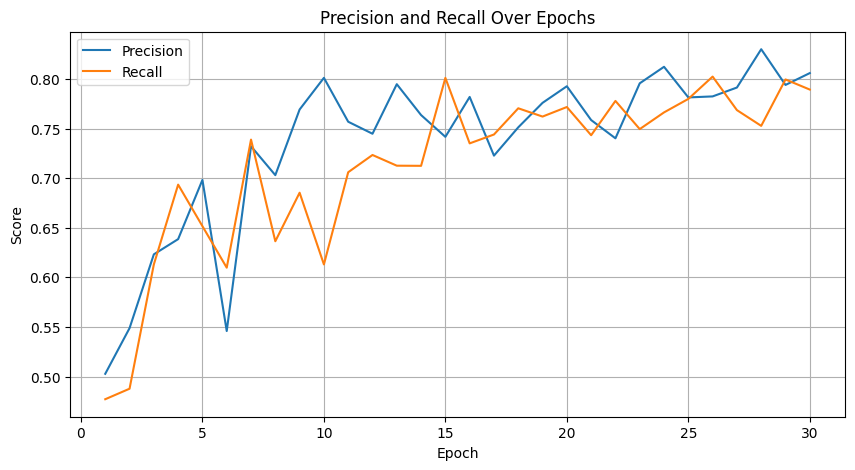

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results
results = pd.read_csv("/content/helmet_yolov8_runs/exp/results.csv")
results = results.fillna(method='ffill')  # Fill missing values

# Inspect columns
print(results.columns)

# Plot losses
plt.figure(figsize=(10,5))
plt.plot(results["epoch"], results["train/box_loss"], label="Train Box Loss")
plt.plot(results["epoch"], results["train/cls_loss"], label="Train Cls Loss")
plt.plot(results["epoch"], results["train/dfl_loss"], label="Train Dfl Loss")
plt.plot(results["epoch"], results.get("val/box_loss", []), label="Val Box Loss", linestyle="--")
plt.plot(results["epoch"], results.get("val/cls_loss", []), label="Val Cls Loss", linestyle="--")
plt.plot(results["epoch"], results.get("val/dfl_loss", []), label="Val Dfl Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Losses")
plt.legend()
plt.grid(True)
plt.show()

# Plot mAP
plt.figure(figsize=(10,5))
plt.plot(results["epoch"], results.get("metrics/mAP50(B)", []), label="mAP@0.5")
plt.plot(results["epoch"], results.get("metrics/mAP50-95(B)", []), label="mAP@0.5:0.95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Plot Precision and Recall
plt.figure(figsize=(10,5))
plt.plot(results["epoch"], results.get("metrics/precision(B)", []), label="Precision")
plt.plot(results["epoch"], results.get("metrics/recall(B)", []), label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision and Recall Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
import pandas as pd
import plotly.graph_objects as go

# Load results
results = pd.read_csv("/content/helmet_yolov8_runs/exp/results.csv")
results = results.fillna(method='ffill')  # Fill missing values

# Create figure
fig = go.Figure()

# Losses
fig.add_trace(go.Scatter(x=results["epoch"], y=results["train/box_loss"], mode='lines+markers', name='Train Box Loss'))
fig.add_trace(go.Scatter(x=results["epoch"], y=results["train/cls_loss"], mode='lines+markers', name='Train Cls Loss'))
fig.add_trace(go.Scatter(x=results["epoch"], y=results["train/dfl_loss"], mode='lines+markers', name='Train Dfl Loss'))

fig.add_trace(go.Scatter(x=results["epoch"], y=results.get("val/box_loss", []), mode='lines+markers', name='Val Box Loss', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=results["epoch"], y=results.get("val/cls_loss", []), mode='lines+markers', name='Val Cls Loss', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=results["epoch"], y=results.get("val/dfl_loss", []), mode='lines+markers', name='Val Dfl Loss', line=dict(dash='dash')))

# mAP
fig.add_trace(go.Scatter(x=results["epoch"], y=results.get("metrics/mAP50(B)", []), mode='lines+markers', name='mAP@0.5'))
fig.add_trace(go.Scatter(x=results["epoch"], y=results.get("metrics/mAP50-95(B)", []), mode='lines+markers', name='mAP@0.5:0.95'))

# Precision & Recall
fig.add_trace(go.Scatter(x=results["epoch"], y=results.get("metrics/precision(B)", []), mode='lines+markers', name='Precision'))
fig.add_trace(go.Scatter(x=results["epoch"], y=results.get("metrics/recall(B)", []), mode='lines+markers', name='Recall'))

# Layout
fig.update_layout(
    title="YOLOv8 Training Metrics",
    xaxis_title="Epoch",
    yaxis_title="Score / Loss",
    hovermode="x unified"
)

fig.show()


# 🔍 Inference on Test Set

After training, we evaluate the model on unseen test images.

- We load the **best weights (`best.pt`)**.
- Run inference on the test set.
- Save predictions to `runs/detect/exp/`.

Parameter:
- **conf=0.25** → detections below this confidence score are ignored.



image 1/1 /content/Bike-Helmet-Detection-2/test/images/BikesHelmets409_png_jpg.rf.13d69cfea44941c046cfd433fed8e67c.jpg: 640x640 2 With Helmets, 16.2ms
Speed: 2.5ms preprocess, 16.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


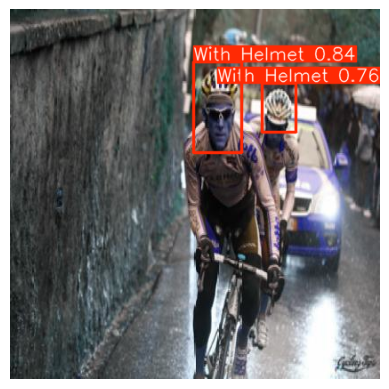

In [38]:
import random
# Load best model
best_model = YOLO("/content/helmet_yolov8_runs/exp/weights/best.pt")

# Test images directory
test_dir = "/content/Bike-Helmet-Detection-2/test/images"

# Pick a random test image
sample_img = os.path.join(test_dir, random.choice(os.listdir(test_dir)))

# Run inference
pred = best_model.predict(sample_img, conf=0.25, save=False)

# Display output
for r in pred:
    im_array = r.plot()
    plt.imshow(im_array)
    plt.axis("off")
    plt.show()